<a href="https://colab.research.google.com/github/EdmundoMarquez/AnalisisDatos_IA/blob/main/Proyecto_Introducci%C3%B3n_al_An%C3%A1lisis_de_Exploratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: ANÁLISIS DE EXPLORATORIO DE DATOS**

Una vez visto el ***Módulo 3: Introducción al Análisis de Datos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar todo el proceso que involucra el **análisis de datos** donde el tema a emplear es libre ya que dependerá del **dataset a escoger**. Cada **proceso del análisis** deberá ser mostrado en este notebook:

*   **Recopilación de datos.**
*   **Limpieza de datos.**
*   **Exploración de datos.**
*   **Visualización de datos.**

# Recopilación de datos

In [103]:
# Verificamos que los módulos si estén instalados
!pip install opendatasets
!pip install pandas

In [104]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [105]:
# Importamos desde Kaggle el dataset más reciente de juegos lanzados en Steam
import kagglehub
path = kagglehub.dataset_download("nikdavis/steam-store-games")

Using Colab cache for faster access to the 'steam-store-games' dataset.


In [106]:
df_steam = pd.read_csv(f"{path}/steam.csv")
df_steam

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27070,1065230,Room of Pandora,2019-04-24,1,SHEN JIAWEI,SHEN JIAWEI,windows,0,Single-player;Steam Achievements,Adventure;Casual;Indie,Adventure;Indie;Casual,7,3,0,0,0,0-20000,2.09
27071,1065570,Cyber Gun,2019-04-23,1,Semyon Maximov,BekkerDev Studio,windows,0,Single-player,Action;Adventure;Indie,Action;Indie;Adventure,0,8,1,0,0,0-20000,1.69
27072,1065650,Super Star Blast,2019-04-24,1,EntwicklerX,EntwicklerX,windows,0,Single-player;Multi-player;Co-op;Shared/Split ...,Action;Casual;Indie,Action;Indie;Casual,24,0,1,0,0,0-20000,3.99
27073,1066700,New Yankee 7: Deer Hunters,2019-04-17,1,Yustas Game Studio,Alawar Entertainment,windows;mac,0,Single-player;Steam Cloud,Adventure;Casual;Indie,Indie;Casual;Adventure,0,2,0,0,0,0-20000,5.19


In [107]:
# Verificar tipos de datos y no nulos
# La única columna con nulos es la de 'publishers'
df_steam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

In [108]:
# Extraemos todas las columnas a las que se les puede realizar un resumen estadístico
columnas_numericas = ["positive_ratings", "negative_ratings", "average_playtime", "median_playtime", "price", "achievements"]
df_steam[columnas_numericas].describe()

,positive_ratings,negative_ratings,average_playtime,median_playtime,price,achievements
count,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000,27075.000000
mean,1.000559e+03,211.027147,149.804949,146.05603,6.078193,45.248864
std,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922,352.670281
min,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000
25%,6.000000e+00,2.000000,0.000000,0.00000,1.690000,0.000000
50%,2.400000e+01,9.000000,0.000000,0.00000,3.990000,7.000000
75%,1.260000e+02,42.000000,0.000000,0.00000,7.190000,23.000000
max,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000,9821.000000


In [109]:
3# Los datos más recientes del dataset son del 2019
df_steam['release_date'] = pd.to_datetime(df_steam['release_date'], format='%Y-%m-%d')

print(f"Most recent data for dataset: {df_steam["release_date"].max()}")
print(f"Most older data for dataset: {df_steam["release_date"].min()}")

# games_launched_recently = df_steam[df_steam["release_date"].dt.year == df_steam["release_date"].max().year]

# games_launched_recently


Most recent data for dataset: 2019-05-01 00:00:00
Most older data for dataset: 1997-06-30 00:00:00


## Datos categóricos

In [110]:
df_steam["platforms"].unique()

array(['windows;mac;linux', 'windows;mac', 'windows', 'windows;linux',
       'mac', 'mac;linux', 'linux'], dtype=object)

In [111]:
df_steam["required_age"].unique()

array([ 0, 18, 16, 12,  7,  3])

In [112]:
df_steam["developer"].unique()

array(['Valve', 'Gearbox Software', 'Valve;Hidden Path Entertainment',
       ..., 'SHEN JIAWEI', 'Semyon Maximov', 'Adept Studios GD'],
      dtype=object)

In [113]:
df_steam["publisher"].unique()

array(['Valve', 'Mark Healey', 'Tripwire Interactive', ..., 'MonteCube',
       'Velvet Paradise Games', 'SHEN JIAWEI'], dtype=object)

In [114]:
# Se requiere separar las categorías combinadas de "categories", "genre" y "steamspy_tags" que hay en cada
# registro, ya que será difícil hacer un análisis clasificatorio si no se separan
df_steam["categories"].unique()

array(['Multi-player;Online Multi-Player;Local Multi-Player;Valve Anti-Cheat enabled',
       'Multi-player;Valve Anti-Cheat enabled',
       'Single-player;Multi-player;Valve Anti-Cheat enabled', ...,
       'Online Multi-Player;Steam Achievements;Full controller support;In-App Purchases;Steam Cloud',
       'Multi-player;Local Multi-Player;Co-op;Local Co-op;Shared/Split Screen',
       'Multi-player;Online Multi-Player;Cross-Platform Multiplayer;Stats'],
      dtype=object)

In [115]:
# Categoría combinada de géneros de juego
df_steam["genres"].unique()

array(['Action', 'Action;Free to Play', 'Action;Free to Play;Strategy',
       ...,
       'Action;Adventure;Indie;Massively Multiplayer;RPG;Strategy;Early Access',
       'Action;Adventure;Casual;Free to Play;Indie;RPG;Simulation;Sports;Strategy',
       'Casual;Free to Play;Massively Multiplayer;RPG;Early Access'],
      dtype=object)

In [116]:
# Categoría combinada de etiquetas que usa el algoritmo de Steam para SEO
df_steam["steamspy_tags"].unique()

array(['Action;FPS;Multiplayer', 'FPS;World War II;Multiplayer',
       'FPS;Action;Sci-fi', ..., 'Casual;Adventure;Arcade',
       'Free to Play;Visual Novel',
       'Early Access;Adventure;Sexual Content'], dtype=object)

In [117]:
# Función que separa cada valor por ; de categorías combinadas y
# devuelve un array con todos los valores únicos sin repetir
def separate_multiple_category(df, category):
  categories = df[category].unique()
  categories_split = []
  for category in categories:
    split_cat = category.split(";")
    for cat in split_cat:
        if cat not in categories_split:
            categories_split.append(cat)
  return categories_split


In [118]:
print(f"Categorías únicas: \n{separate_multiple_category(df_steam, "categories")}")
print(f"Géneros únicos: \n{separate_multiple_category(df_steam, "genres")}")
print(f"Etiquetas Steam únicas: \n{separate_multiple_category(df_steam, "steamspy_tags")}")

Categorías únicas: 
['Multi-player', 'Online Multi-Player', 'Local Multi-Player', 'Valve Anti-Cheat enabled', 'Single-player', 'Steam Cloud', 'Steam Achievements', 'Steam Trading Cards', 'Captions available', 'Partial Controller Support', 'Includes Source SDK', 'Cross-Platform Multiplayer', 'Stats', 'Commentary available', 'Includes level editor', 'Steam Workshop', 'In-App Purchases', 'Co-op', 'Full controller support', 'Steam Leaderboards', 'SteamVR Collectibles', 'Online Co-op', 'Shared/Split Screen', 'Local Co-op', 'MMO', 'VR Support', 'Mods', 'Mods (require HL2)', 'Steam Turn Notifications']
Géneros únicos: 
['Action', 'Free to Play', 'Strategy', 'Adventure', 'Indie', 'RPG', 'Animation & Modeling', 'Video Production', 'Casual', 'Simulation', 'Racing', 'Violent', 'Massively Multiplayer', 'Nudity', 'Sports', 'Early Access', 'Gore', 'Utilities', 'Design & Illustration', 'Web Publishing', 'Education', 'Software Training', 'Sexual Content', 'Audio Production', 'Game Development', 'Photo

In [119]:
# Es difícil determinar la cantidad de dueños con este tipo de datos
# Así que se mantendrá como categoría
df_steam["owners"].unique()

array(['10000000-20000000', '5000000-10000000', '2000000-5000000',
       '20000000-50000000', '100000000-200000000', '50000000-100000000',
       '20000-50000', '500000-1000000', '100000-200000', '50000-100000',
       '1000000-2000000', '200000-500000', '0-20000'], dtype=object)

In [120]:
# Cambiar esta columna a una mejor clasificación? Sólo determina si el juego
# está en inglés o no
df_steam["english"].unique()

array([1, 0])

# Limpieza de datos

In [121]:
df_steam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   appid             27075 non-null  int64         
 1   name              27075 non-null  object        
 2   release_date      27075 non-null  datetime64[ns]
 3   english           27075 non-null  int64         
 4   developer         27074 non-null  object        
 5   publisher         27061 non-null  object        
 6   platforms         27075 non-null  object        
 7   required_age      27075 non-null  int64         
 8   categories        27075 non-null  object        
 9   genres            27075 non-null  object        
 10  steamspy_tags     27075 non-null  object        
 11  achievements      27075 non-null  int64         
 12  positive_ratings  27075 non-null  int64         
 13  negative_ratings  27075 non-null  int64         
 14  average_playtime  2707

In [122]:
# Verificar valores nulos por columna de texto
columnas_texto = ['name','publisher', 'developer']
print(df_steam[columnas_texto].isnull().sum())

name          0
publisher    14
developer     1
dtype: int64


In [123]:
#Verificar los datos nulos de la columna "publisher"
df_steam[df_steam["publisher"].isnull()].head(10)

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
3420,307170,Borealis,2014-09-02,1,Conrad Nelson,NaN,windows,0,Single-player;Steam Achievements;Steam Trading...,Action;Casual;Indie,Casual;Indie;Action,17,301,192,132,146,50000-100000,3.99
4511,341120,Glorkian Warrior: The Trials Of Glork,2015-03-24,1,Pixeljam,NaN,windows;mac,0,Single-player;Steam Achievements;Full controll...,Indie,Indie;Platformer;Shoot 'Em Up,18,234,26,274,274,20000-50000,2.79
5229,359370,Pirate's Life,2015-04-17,1,Team Eyepatch,NaN,windows,0,Single-player,Simulation;Strategy,Strategy;Simulation;Pirates,0,25,41,0,0,0-20000,3.99
7464,422940,Divergence: Online,2016-01-06,1,Stained Glass Llama,NaN,windows,0,Multi-player;MMO;Steam Turn Notifications,Action;Indie;Massively Multiplayer;RPG;Early A...,Early Access;Massively Multiplayer;Indie,0,72,51,0,0,0-20000,14.99
7911,436240,Melancholy Republic,2018-04-12,1,Cloud Runner Studios,NaN,windows,0,Single-player,Adventure;Casual;Indie,Adventure;Indie;Casual,0,14,6,0,0,0-20000,6.99
9894,498710,After Dreams,2018-05-06,1,Matt Boyer,NaN,windows,0,Single-player,Violent;Adventure;Casual;Free to Play;Indie;Si...,Free to Play;Adventure;Indie,0,126,47,1,1,20000-50000,0.00
10011,502150,Interstellar Logistics Inc,2016-08-15,1,Exalted Guy Interactive,NaN,windows,0,Single-player,Casual,Casual;Puzzle;Sci-fi,9,25,4,281,281,0-20000,2.09
10564,516430,Ruin of the Reckless,2017-04-26,1,Faux-Operative Games,NaN,windows,0,Single-player;Co-op;Local Co-op;Shared/Split S...,Action;Adventure;Indie;RPG,Action;Indie;Adventure,0,63,11,0,0,0-20000,6.99
11123,531240,Max Stern,2016-10-21,1,Lupan Artiom Oleg,NaN,windows;mac;linux,0,Single-player;Steam Achievements;Steam Trading...,Action;Adventure;Indie,Action;Indie;Adventure,10,17,13,266,266,0-20000,3.99
13901,610740,SuperCluster: Void,2017-05-15,1,Logan McClure,NaN,windows,0,Single-player,Adventure;Indie;RPG,Adventure;RPG;Indie,0,16,4,0,0,0-20000,3.99


In [124]:
df_steam["publisher"] = df_steam["publisher"].fillna("No Publisher")

In [125]:
# Verificar los datos nulos de la columna "developer"
df_steam[df_steam["developer"].isnull()].head(10)

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
23071,881910,The Battle Of Ages,2018-09-07,1,NaN,No Publisher,windows,0,Multi-player;Online Multi-Player,Action;Indie;Massively Multiplayer;RPG;Early A...,Early Access;Action;Massively Multiplayer,0,2,1,0,0,0-20000,3.99


In [126]:
df_steam["developer"] = df_steam["developer"].fillna("No Developer")

In [127]:
print(df_steam[columnas_texto].isnull().sum())

name         0
publisher    0
developer    0
dtype: int64


In [128]:
df_steam['required_age'] = df_steam['required_age'].astype('category')

print("=== TIPOS DE DATOS ===")
df_steam.info()

=== TIPOS DE DATOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   appid             27075 non-null  int64         
 1   name              27075 non-null  object        
 2   release_date      27075 non-null  datetime64[ns]
 3   english           27075 non-null  int64         
 4   developer         27075 non-null  object        
 5   publisher         27075 non-null  object        
 6   platforms         27075 non-null  object        
 7   required_age      27075 non-null  category      
 8   categories        27075 non-null  object        
 9   genres            27075 non-null  object        
 10  steamspy_tags     27075 non-null  object        
 11  achievements      27075 non-null  int64         
 12  positive_ratings  27075 non-null  int64         
 13  negative_ratings  27075 non-null  int64         
 14 

# Exploración de datos

## Rango Intercuartílico

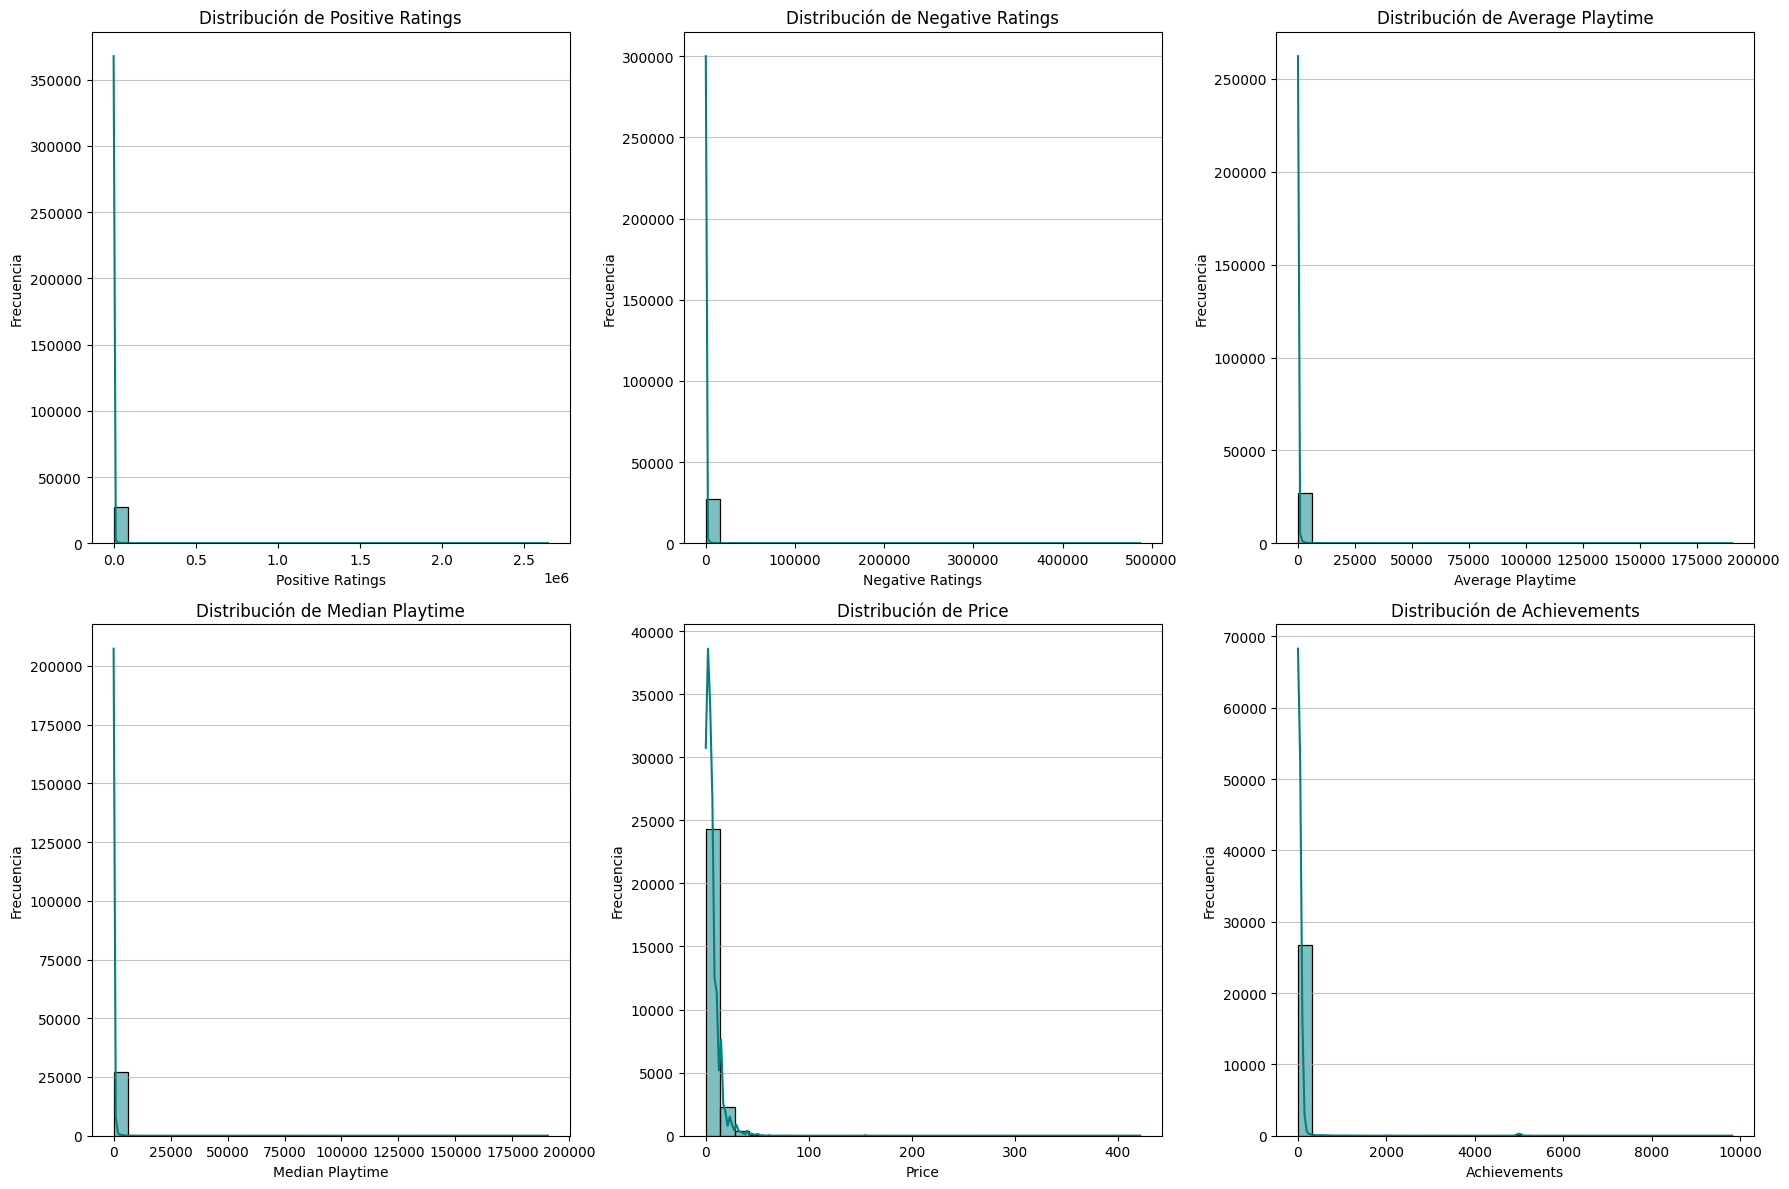

In [129]:
# Observar distribución de los datos

plt.figure(figsize=(18, 12))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_steam[col], bins=30, kde=True, color='teal')
    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

# Los datos de average_playtime y median_playtime tienen demasiados registros
# cercanos a cero, esto no ayuda a determinar la naturaleza de las columnas
# ya que implica que gran parte de los usuarios no ha jugado el juego.
# La mayoría de las distribuciones no son normales y tienen valores extremos.

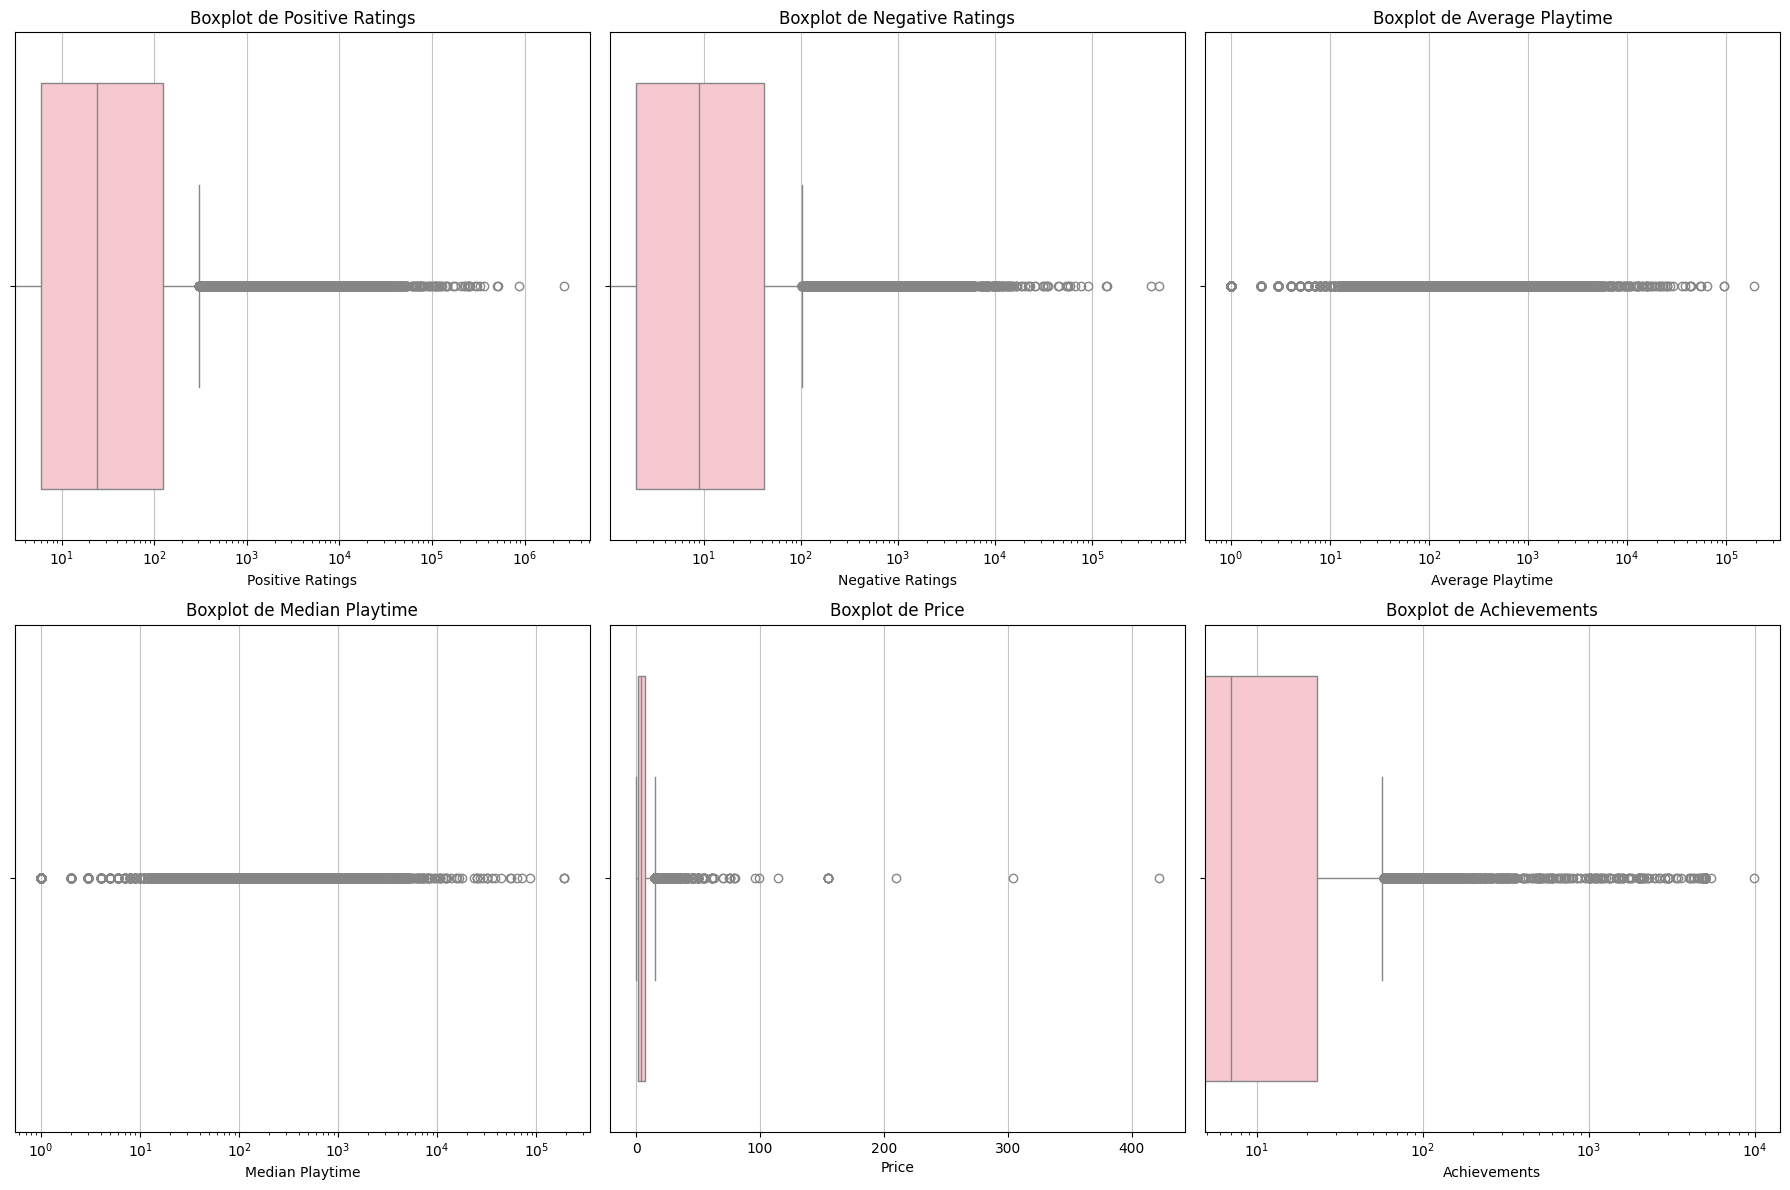

In [130]:
# Observar comportamiento cuartil de los datos

plt.figure(figsize=(18, 12))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_steam[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

    # Aplicar escala para columnas con frecuencias de 10n
    if col in ["positive_ratings", "negative_ratings", "average_playtime", "median_playtime", "achievements"]:
        plt.xscale('log')
        plt.xlabel(f'{col.replace("_", " ").title()}')

plt.tight_layout()
plt.show()
# Todos los gráficos de caja muestran valores extremos

In [131]:
df_steam[columnas_numericas].describe()

,positive_ratings,negative_ratings,average_playtime,median_playtime,price,achievements
count,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000,27075.000000
mean,1.000559e+03,211.027147,149.804949,146.05603,6.078193,45.248864
std,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922,352.670281
min,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000
25%,6.000000e+00,2.000000,0.000000,0.00000,1.690000,0.000000
50%,2.400000e+01,9.000000,0.000000,0.00000,3.990000,7.000000
75%,1.260000e+02,42.000000,0.000000,0.00000,7.190000,23.000000
max,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000,9821.000000


In [132]:
zero_playtime_mask = (df_steam['average_playtime'] == 0) & (df_steam['median_playtime'] == 0)
zero_playtime_count = zero_playtime_mask.sum()
zero_playtime_percentage = (zero_playtime_count / len(df_steam)) * 100

print(f"Number of games with zero average and median playtime: {zero_playtime_count}")
print(f"Percentage of games with zero average and median playtime: {zero_playtime_percentage:.2f}%")

Number of games with zero average and median playtime: 20905
Percentage of games with zero average and median playtime: 77.21%


In [133]:
df_steam['playtime_segment'] = df_steam.apply(lambda row: 'zero_playtime' if row['average_playtime'] == 0 and row['median_playtime'] == 0 else 'non_zero_playtime', axis=1)
print(df_steam['playtime_segment'].value_counts())

playtime_segment
zero_playtime        20905
non_zero_playtime     6170
Name: count, dtype: int64


In [134]:
df_non_zero_playtime = df_steam[df_steam['playtime_segment'] == 'non_zero_playtime'].copy()
print(f"Shape of df_non_zero_playtime: {df_non_zero_playtime.shape}")
df_non_zero_playtime.head(10)

Shape of df_non_zero_playtime: (6170, 19)


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price,playtime_segment
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19,non_zero_playtime
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99,non_zero_playtime
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99,non_zero_playtime
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99,non_zero_playtime
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99,non_zero_playtime
5,60,Ricochet,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Valve Anti-Ch...,Action,Action;FPS;Multiplayer,0,2758,684,175,10,5000000-10000000,3.99,non_zero_playtime
6,70,Half-Life,1998-11-08,1,Valve,Valve,windows;mac;linux,0,Single-player;Multi-player;Online Multi-Player...,Action,FPS;Classic;Action,0,27755,1100,1300,83,5000000-10000000,7.19,non_zero_playtime
7,80,Counter-Strike: Condition Zero,2004-03-01,1,Valve,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,Action;FPS;Multiplayer,0,12120,1439,427,43,10000000-20000000,7.19,non_zero_playtime
8,130,Half-Life: Blue Shift,2001-06-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player,Action,FPS;Action;Sci-fi,0,3822,420,361,205,5000000-10000000,3.99,non_zero_playtime
9,220,Half-Life 2,2004-11-16,1,Valve,Valve,windows;mac;linux,0,Single-player;Steam Achievements;Steam Trading...,Action,FPS;Action;Sci-fi,33,67902,2419,691,402,10000000-20000000,7.19,non_zero_playtime


In [135]:
df_copy = df_non_zero_playtime.copy() # Preservar el dataset haciendo una copia

In [136]:
# Ver cantidad de registros iniciales

print(f'Cantidad de datos iniciales: {len(df_copy)}')

Cantidad de datos iniciales: 6170


In [137]:
# Calculo del IQR

for col in columnas_numericas:

  Q1 = df_copy[col].quantile(0.25) # Primer cuartil
  Q3 = df_copy[col].quantile(0.75) # Tercer cuartil
  IQR = Q3 - Q1 # Rango intercuartilico

  lim_inf_iqr = Q1 - 1.5 * IQR # Limite inferior
  lim_sup_iqr = Q3 + 1.5 * IQR # Limite superior

  cant_inicial = len(df_copy)
  # Filtro de los datos dentro de los limites
  df_copy = df_copy[(df_copy[col] >= lim_inf_iqr) & (df_copy[col] <= lim_sup_iqr)]
  cant_final = len(df_copy)

  print(f"Columna '{col}': Se eliminaron {cant_inicial - cant_final} registros.")


Columna 'positive_ratings': Se eliminaron 850 registros.
Columna 'negative_ratings': Se eliminaron 514 registros.
Columna 'average_playtime': Se eliminaron 358 registros.
Columna 'median_playtime': Se eliminaron 66 registros.
Columna 'price': Se eliminaron 198 registros.
Columna 'achievements': Se eliminaron 226 registros.


In [138]:
# Ver cantidad de registros finales y proporción con la cantidad inicial

prop_cant_datos = round((len(df_copy) / (len(df_non_zero_playtime)) * 100), 2)

print(f'Cantidad de datos finales: {len(df_copy)}')
print(f'Los datos finales representan el {prop_cant_datos}% de los datos iniciales')

Cantidad de datos finales: 3958
Los datos finales representan el 64.15% de los datos iniciales


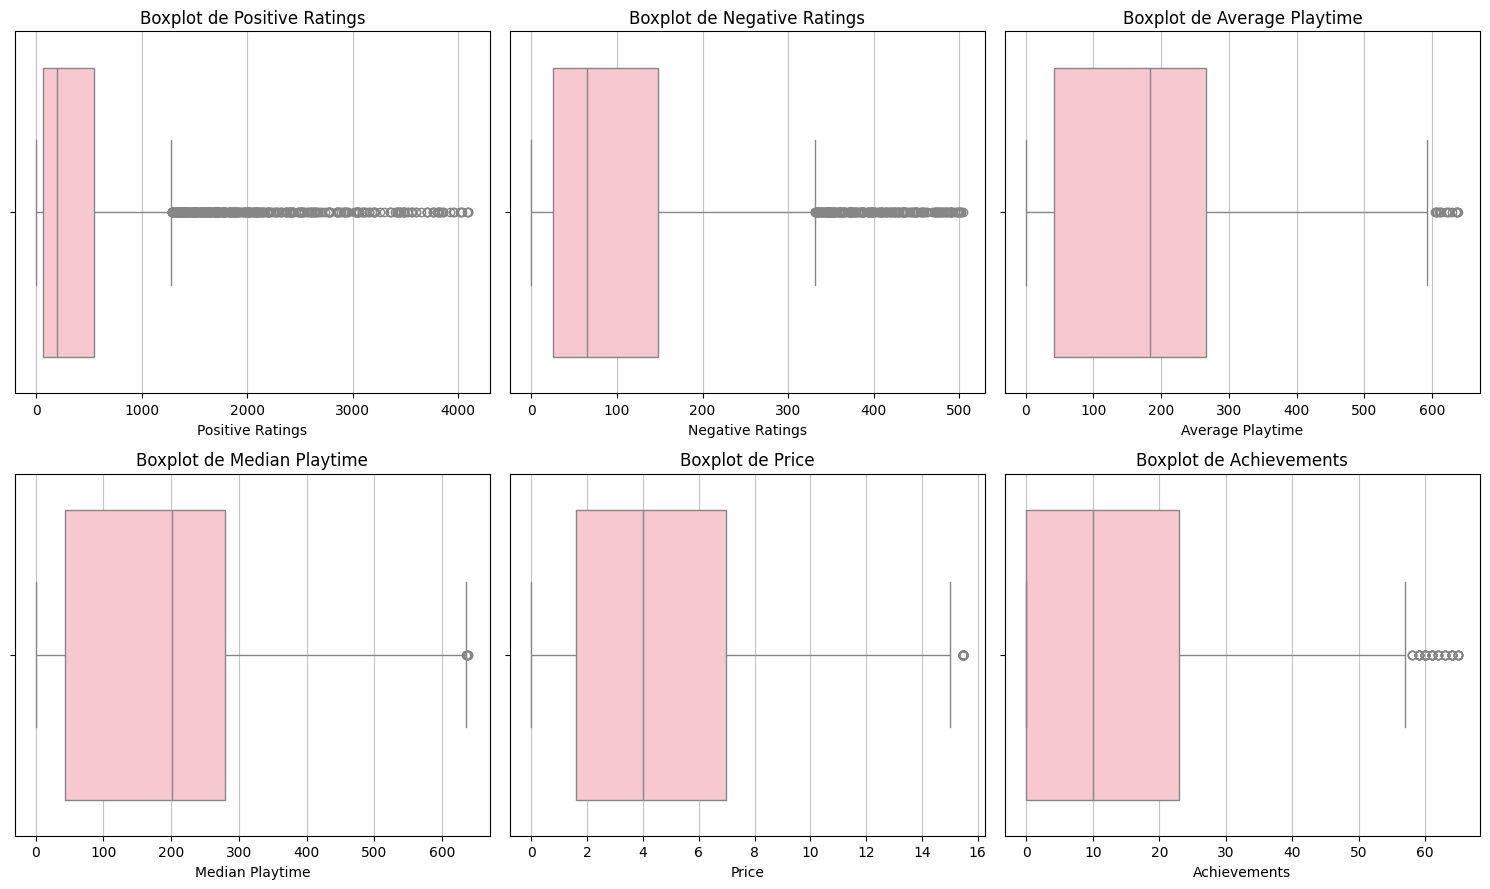

In [139]:
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_copy[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

In [140]:
df_copy

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price,playtime_segment
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99,non_zero_playtime
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99,non_zero_playtime
8,130,Half-Life: Blue Shift,2001-06-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player,Action,FPS;Action;Sci-fi,0,3822,420,361,205,5000000-10000000,3.99,non_zero_playtime
15,360,Half-Life Deathmatch: Source,2006-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,Action;FPS;Multiplayer,0,1362,473,102,81,5000000-10000000,0.00,non_zero_playtime
27,1200,Red Orchestra: Ostfront 41-45,2006-03-14,1,Tripwire Interactive,Tripwire Interactive,windows;mac;linux,0,Multi-player;Steam Achievements;Valve Anti-Che...,Action,World War II;Action;FPS,44,1562,223,232,258,500000-1000000,3.99,non_zero_playtime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26468,1020340,Audica,2019-03-07,1,"Harmonix Music Systems, Inc","Harmonix Music Systems, Inc",windows,0,Single-player,Action;Indie;Early Access,Early Access;Rhythm;Music,0,132,34,17,17,0-20000,15.49,non_zero_playtime
26481,1020820,KumaKuma Manga Editor,2019-02-27,1,KumaKumaManga,SakuraGame,windows,0,Steam Achievements,Animation & Modeling;Design & Illustration;Web...,Design & Illustration;Web Publishing;Animation...,14,346,41,43,43,20000-50000,4.79,non_zero_playtime
26681,1031480,東方幕華祭 春雪篇 ～ Fantastic Danmaku Festival Part II,2019-03-18,1,东方幕华祭制作组,东方幕华祭制作组,windows,0,Single-player;Steam Achievements;Partial Contr...,Indie,Indie;Bullet Hell;Faith,27,619,19,154,154,0-20000,10.29,non_zero_playtime
26856,1043180,Lovers of Aether,2019-04-01,1,Dan Fornace,Dan Fornace,windows;mac,0,Single-player;Steam Cloud,Casual;Indie;Simulation,Psychological Horror;Dating Sim;Casual,15,651,29,12,12,50000-100000,0.00,non_zero_playtime


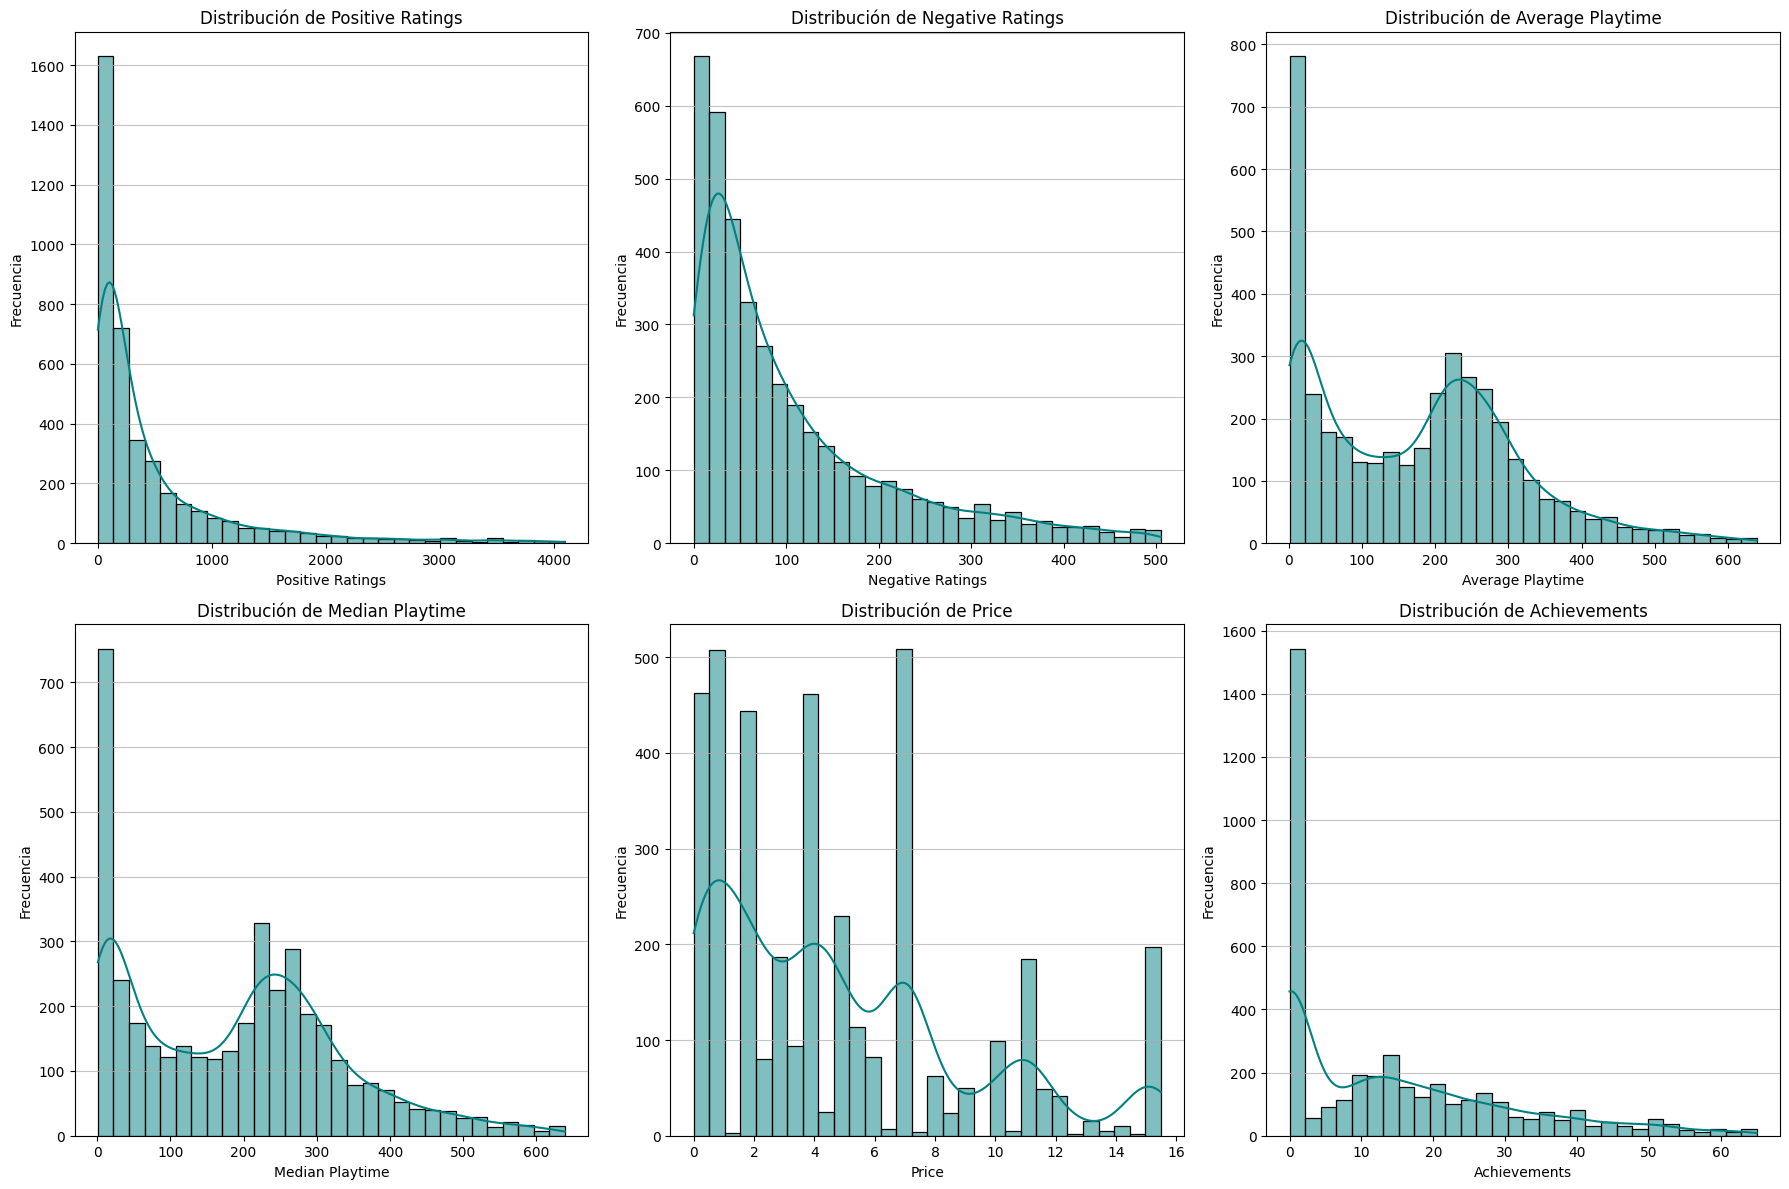

In [141]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_copy[col], bins=30, kde=True, color='teal')
    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

# Visualización de datos

## Correlación numérica

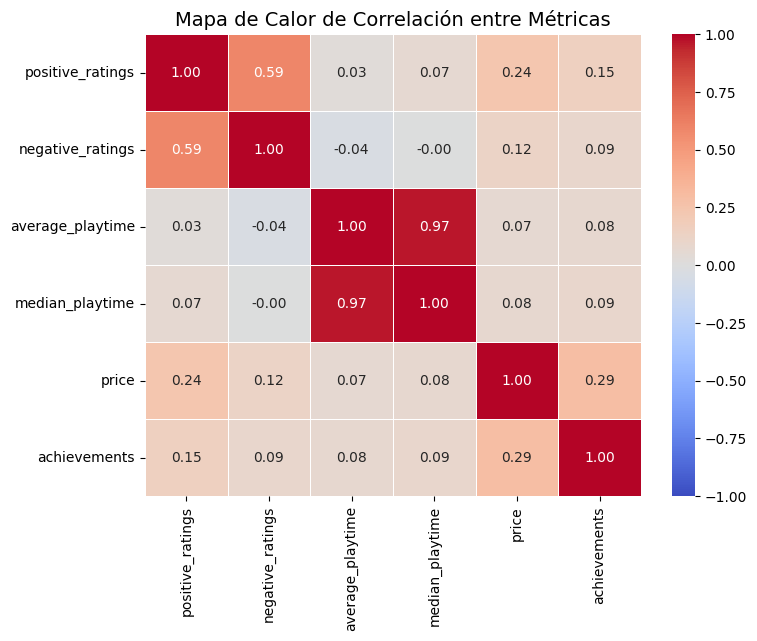

In [142]:
# Realizar matriz de correlación

corr_matrix = df_copy[["positive_ratings", "negative_ratings", "average_playtime", "median_playtime", "price", "achievements"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Mapa de Calor de Correlación entre Métricas', fontsize=14)
plt.show()

# Los coeficientes de las intersecciones convergen en 0, no hay correlación

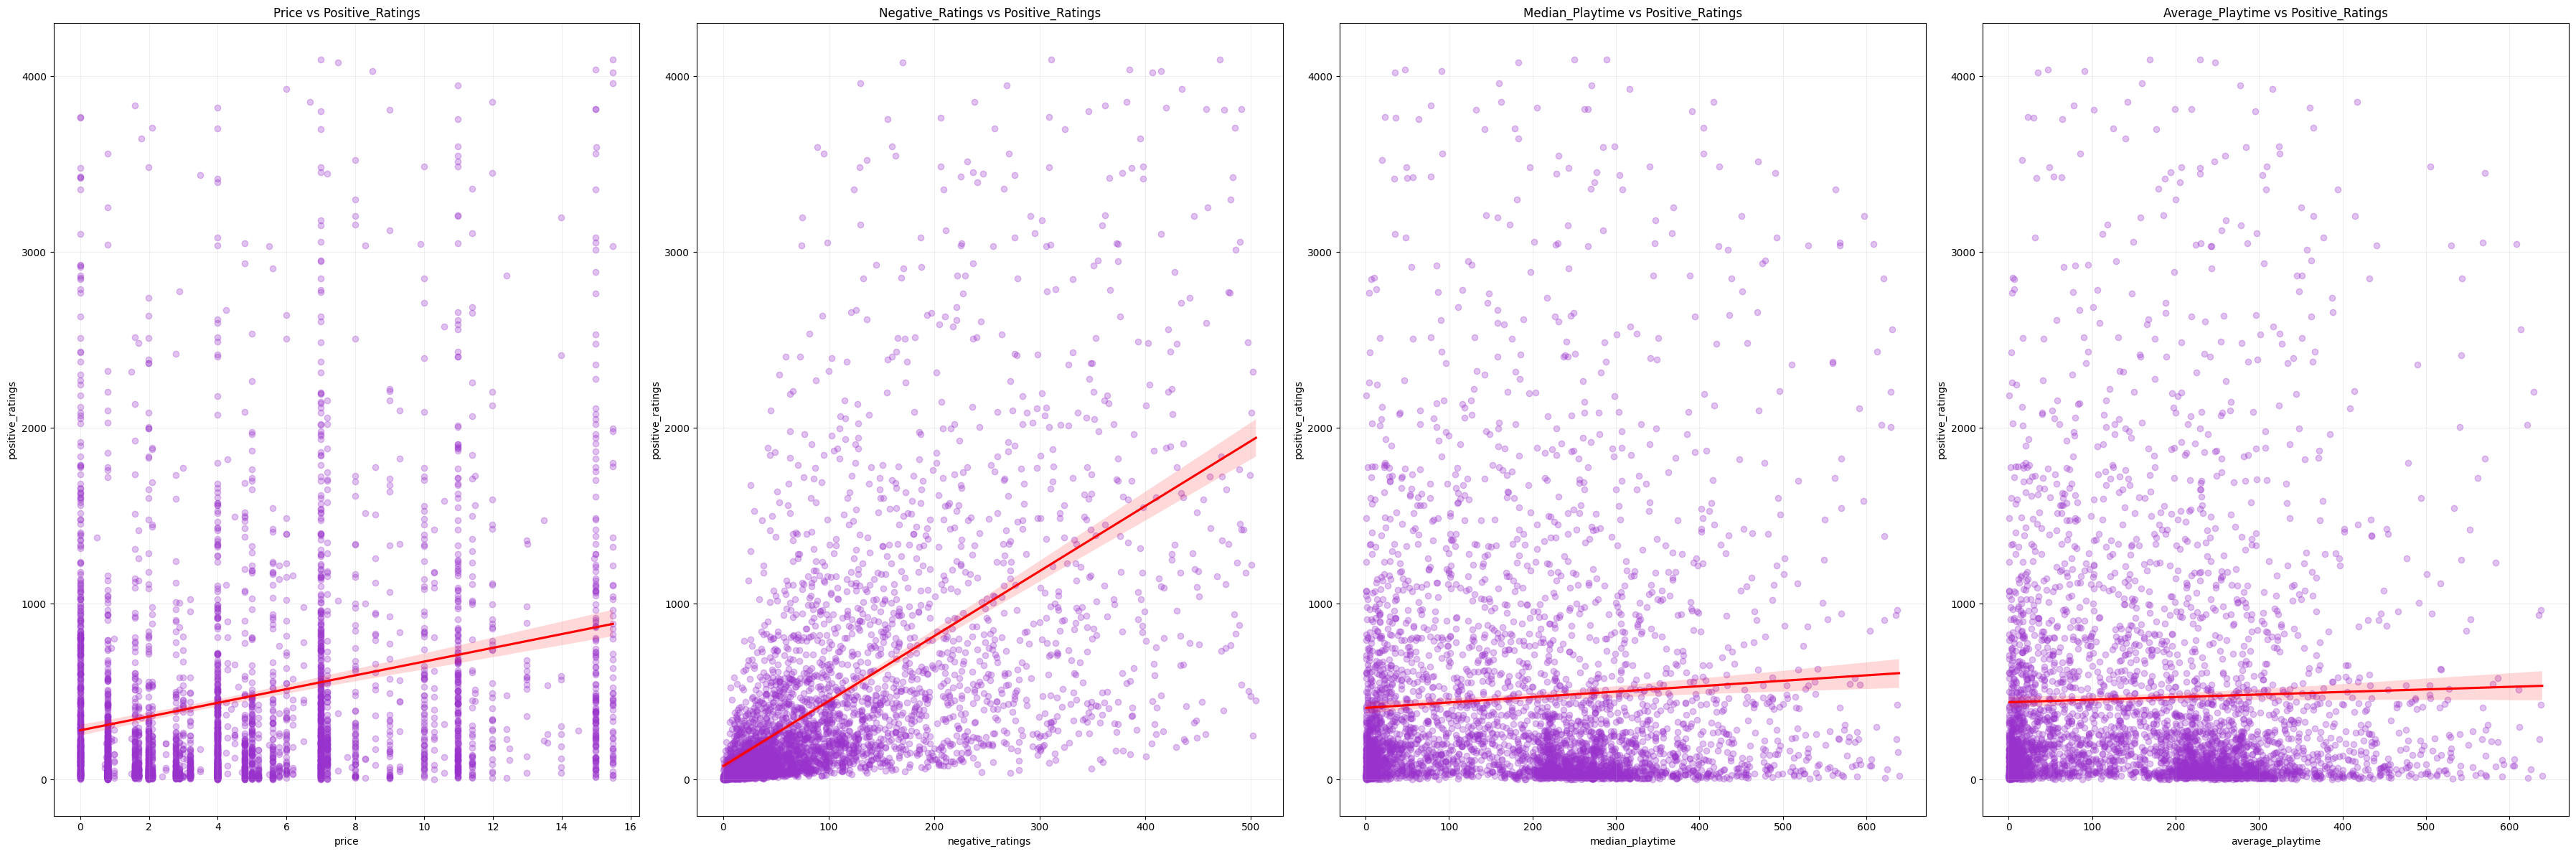

In [143]:
# Realizar correlaciones divididas

metricas = ['positive_ratings', 'negative_ratings', 'price', 'median_playtime', 'average_playtime']

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(36, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Pares de comparación por

comparaciones = [
    ('price', 'positive_ratings'),
    ('negative_ratings', 'positive_ratings'),
    ('median_playtime', 'positive_ratings'),
    ('average_playtime', 'positive_ratings')
]

for i, (col_x, col_y) in enumerate(comparaciones):
    sns.regplot(ax=axes[i], data=df_copy, x=col_x, y=col_y,
                scatter_kws={'alpha':0.3, 'color':'darkorchid'},
                line_kws={'color':'red'})
    axes[i].set_title(f'{col_x.title()} vs {col_y.title()}')
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# La correlación más fuerte se presenta en el comportamiento de los ratings
# A medida que los ratings negativos aumentan, también los positivos

In [144]:
# Obtener todos los géneros únicos del dataset
unique_genres = separate_multiple_category(df_copy, 'genres')

# Crear dataframe con los datos para visualizar separados por género
df_genres = pd.DataFrame({
    'genre': unique_genres,
    'games_count': [0] * len(unique_genres),
    'positive_ratings': [0] * len(unique_genres),
    'negative_ratings': [0] * len(unique_genres),
    'average_playtime': [0] * len(unique_genres)
    })

# Comparar con los géneros combinados del dataset para extraer los datos
# por género
for comb_genre in df_copy['genres']:
  genre_arr = comb_genre.split(";")
  for genre in genre_arr:
    if genre in unique_genres:
      df_genres.loc[df_genres['genre'] == genre, 'games_count'] += 1
      df_genres.loc[df_genres['genre'] == genre, 'positive_ratings'] = df_copy.loc[df_copy['genres'] == comb_genre, 'positive_ratings'].values[0]
      df_genres.loc[df_genres['genre'] == genre, 'negative_ratings'] = df_copy.loc[df_copy['genres'] == comb_genre, 'negative_ratings'].values[0]
      df_genres.loc[df_genres['genre'] == genre, 'average_playtime'] = df_copy.loc[df_copy['genres'] == comb_genre, 'average_playtime'].values[0]

# Ordenar los 15 géneros con los mejores ratings
df_genres = df_genres.sort_values(by='positive_ratings', ascending=False)
df_positive_ratings = df_genres.head(15) # Limitar a 15 registros
# Ordenar los 15 géneros con los peores ratings
df_genres = df_genres.sort_values(by='negative_ratings', ascending=False)
df_negative_ratings = df_genres.head(15) # Limitar a 15 registros
# Ordenar los 15 géneros con los tiempos de juego más largos
df_genres = df_genres.sort_values(by='average_playtime', ascending=False)
df_most_playtime = df_genres.head(15) # Limitar a 15 registros

In [145]:
df_genres

,genre,games_count,positive_ratings,negative_ratings,average_playtime
15,Sexual Content,35,2019,320,621
10,Sports,137,632,192,517
7,Racing,127,199,149,391
3,RPG,632,2936,237,306
23,Photo Editing,1,17,13,293
13,Violent,87,201,255,276
12,Gore,69,201,255,276
2,Strategy,779,151,93,206
4,Simulation,606,959,92,102
6,Casual,1364,959,92,102


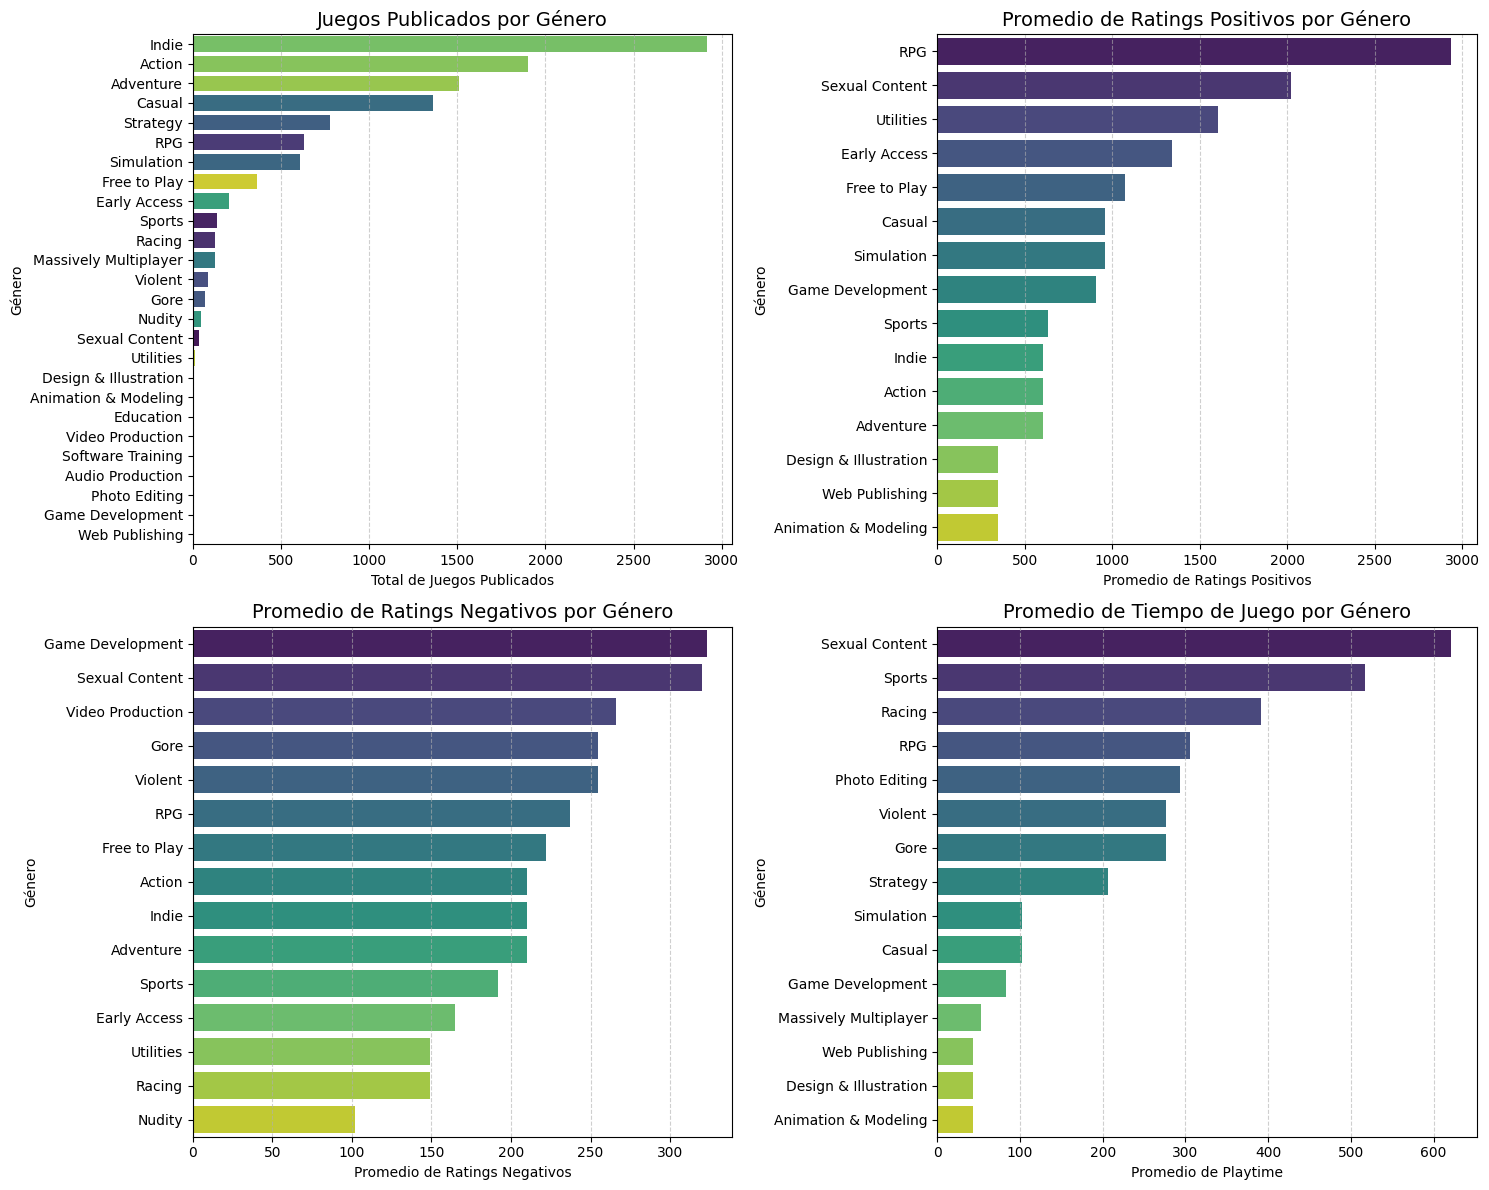

In [146]:
# Realizar gráficos de barras divididas
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
sns.barplot(data=df_genres, x='games_count', y='genre',
            order=df_genres.sort_values('games_count', ascending=False).genre,
            palette='viridis', errorbar=None, hue='genre', legend=False)
plt.title('Juegos Publicados por Género', fontsize=14)
plt.xlabel('Total de Juegos Publicados')
plt.ylabel('Género')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(2, 2, 2)
sns.barplot(data=df_positive_ratings, x='positive_ratings', y='genre',
            estimator='mean', palette='viridis', errorbar=None, hue='genre', legend=False)
plt.title('Promedio de Ratings Positivos por Género', fontsize=14)
plt.xlabel('Promedio de Ratings Positivos')
plt.ylabel('Género')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(2, 2, 3)
sns.barplot(data=df_negative_ratings, x='negative_ratings', y='genre',
            estimator='mean', palette='viridis', errorbar=None, hue='genre', legend=False)
plt.title('Promedio de Ratings Negativos por Género', fontsize=14)
plt.xlabel('Promedio de Ratings Negativos')
plt.ylabel('Género')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(2, 2, 4)
sns.barplot(data=df_most_playtime, x='average_playtime', y='genre',
            estimator='mean', palette='viridis', errorbar=None, hue='genre', legend=False)
plt.title('Promedio de Tiempo de Juego por Género', fontsize=14)
plt.xlabel('Promedio de Playtime')
plt.ylabel('Género')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

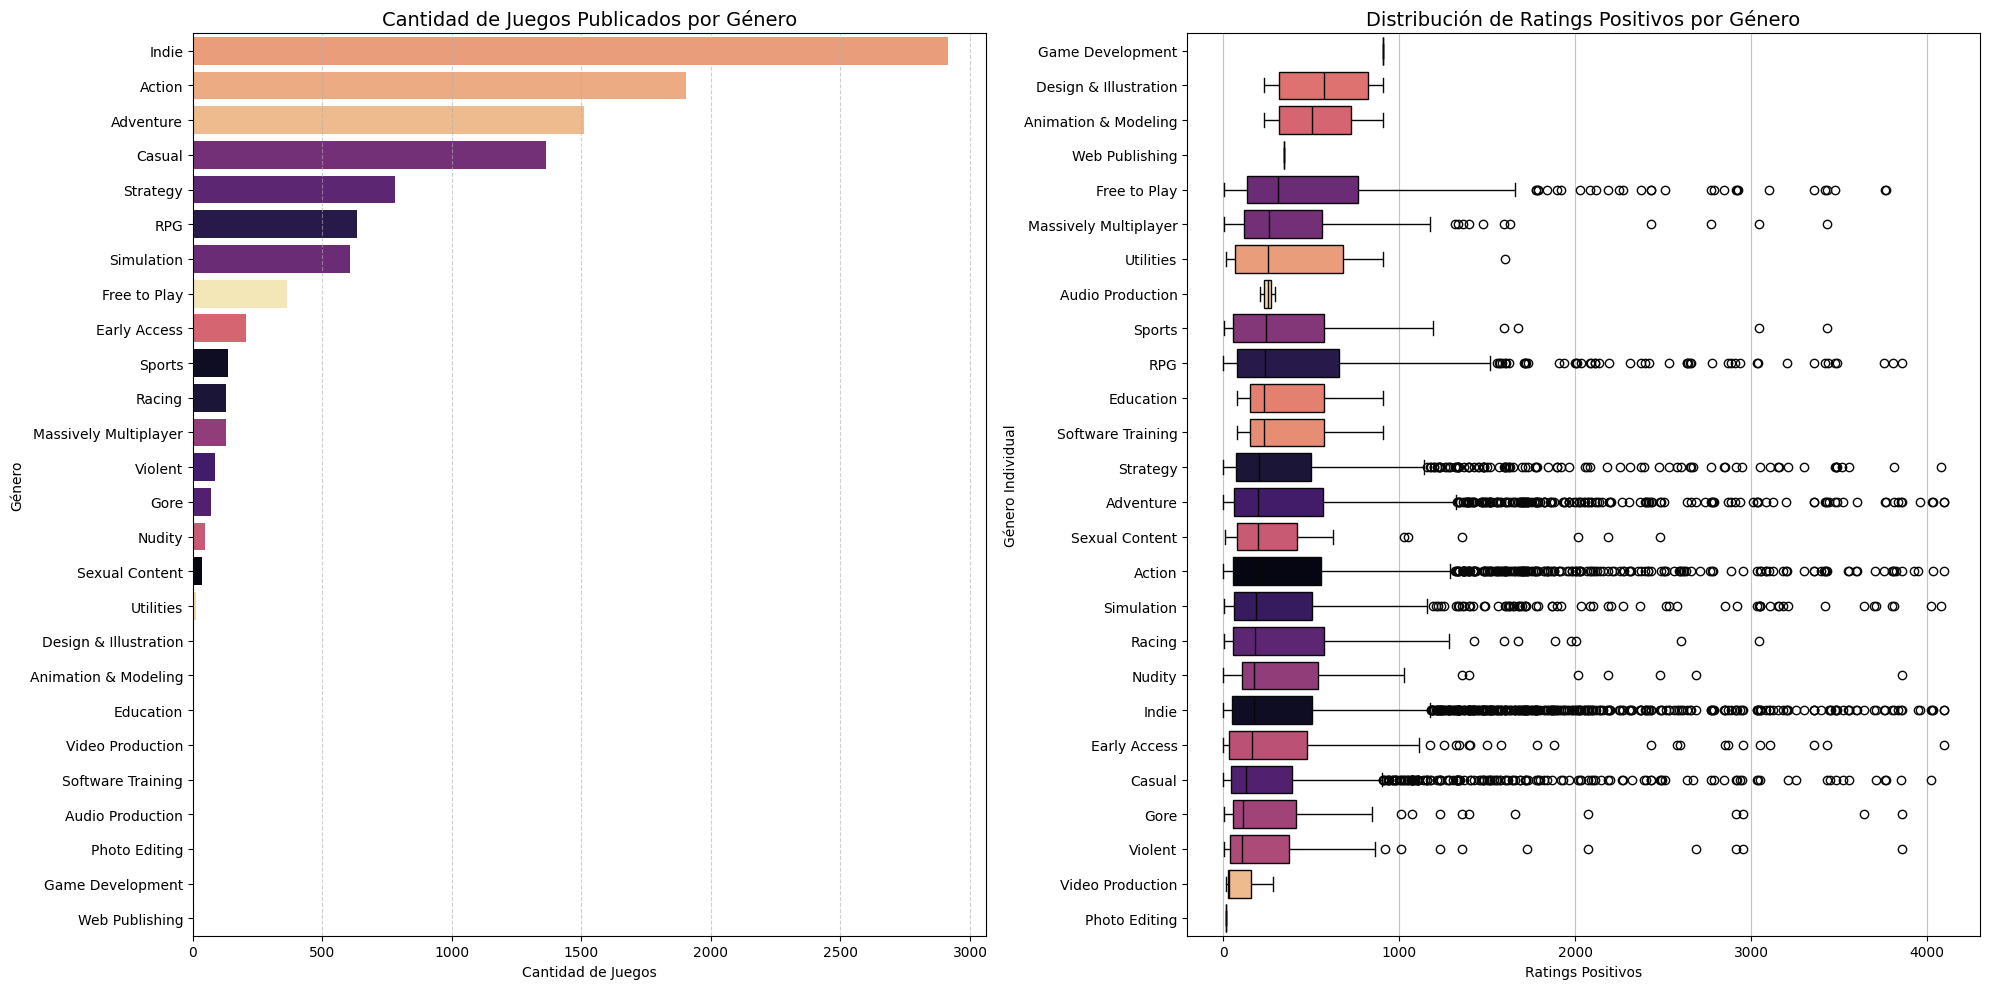

In [147]:
# Realizar gráfico de barras y caja divididos

plt.figure(figsize=(20, 10)) # Increased width for side-by-side plots

plt.subplot(1, 2, 1)
sns.barplot(data=df_genres, x='games_count', y='genre',
            order=df_genres.sort_values('games_count', ascending=False).genre,
            hue='genre', palette='magma', errorbar=None, legend=False)
plt.title('Cantidad de Juegos Publicados por Género', fontsize=14)
plt.xlabel('Cantidad de Juegos')
plt.ylabel('Género')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Realizamos un 'explode' para separar los valores de forma individual sin
# perder el dataset filtrado
df_exploded_genres = df_copy.assign(genre_single=df_copy['genres'].str.split(';')).explode('genre_single')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_exploded_genres, x='positive_ratings', y='genre_single', hue = 'genre_single', palette='magma', legend=False,
            order=df_exploded_genres.groupby('genre_single')['positive_ratings'].median().sort_values(ascending=False).index)
plt.title('Distribución de Ratings Positivos por Género', fontsize=14)
plt.xlabel('Ratings Positivos')
plt.ylabel('Género Individual')
plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

In [148]:
df_exploded_genres

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price,playtime_segment,genre_single
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99,non_zero_playtime,Action
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99,non_zero_playtime,Action
8,130,Half-Life: Blue Shift,2001-06-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player,Action,FPS;Action;Sci-fi,0,3822,420,361,205,5000000-10000000,3.99,non_zero_playtime,Action
15,360,Half-Life Deathmatch: Source,2006-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,Action;FPS;Multiplayer,0,1362,473,102,81,5000000-10000000,0.00,non_zero_playtime,Action
27,1200,Red Orchestra: Ostfront 41-45,2006-03-14,1,Tripwire Interactive,Tripwire Interactive,windows;mac;linux,0,Multi-player;Steam Achievements;Valve Anti-Che...,Action,World War II;Action;FPS,44,1562,223,232,258,500000-1000000,3.99,non_zero_playtime,Action
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26856,1043180,Lovers of Aether,2019-04-01,1,Dan Fornace,Dan Fornace,windows;mac,0,Single-player;Steam Cloud,Casual;Indie;Simulation,Psychological Horror;Dating Sim;Casual,15,651,29,12,12,50000-100000,0.00,non_zero_playtime,Indie
26856,1043180,Lovers of Aether,2019-04-01,1,Dan Fornace,Dan Fornace,windows;mac,0,Single-player;Steam Cloud,Casual;Indie;Simulation,Psychological Horror;Dating Sim;Casual,15,651,29,12,12,50000-100000,0.00,non_zero_playtime,Simulation
26973,1051310,Paper Dolls: Original / 纸人：第一章,2019-04-19,1,"Beijing Litchi Culture Media Co., Ltd.",Gamera Game,windows,0,Single-player;Steam Achievements;Full controll...,Action;Adventure;Indie,Adventure;Action;Indie,28,221,103,347,347,0-20000,13.49,non_zero_playtime,Action
26973,1051310,Paper Dolls: Original / 纸人：第一章,2019-04-19,1,"Beijing Litchi Culture Media Co., Ltd.",Gamera Game,windows,0,Single-player;Steam Achievements;Full controll...,Action;Adventure;Indie,Adventure;Action;Indie,28,221,103,347,347,0-20000,13.49,non_zero_playtime,Adventure


In [149]:
# Definir variables para la agrupación
# Separar los juegos que son free to play de los que son premium
df_copy["pricing_model"] = df_copy["price"].apply(lambda x: "Free to Play" if x == 0 else "Premium")
pie_data = df_copy['pricing_model'].value_counts()

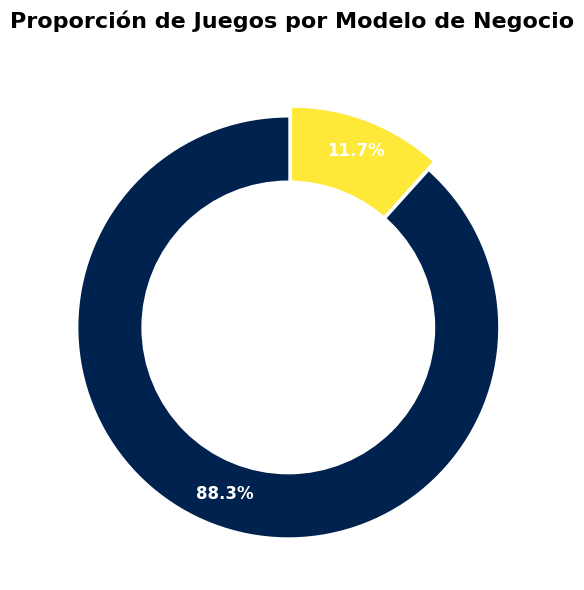

In [150]:
# Realizar gráfico de dona

colors_pie = plt.cm.cividis(np.linspace(0, 1, len(pie_data))) # Colores
explode_val = 0.05 # Valor de separación

# Gráfico de pastel

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(pie_data,
                                   labels=pie_data.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors_pie,
                                   textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'},
                                   pctdistance=0.85, # Mueve el porcentaje hacia afuera
                                   explode=(explode_val, 0)) # Resalta ligeramente la porción principal

# Círculo blanco central (estilo moderno)

theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center_angle = np.deg2rad((theta1 + theta2) / 2) # Obtención el ángulo medio

cx = explode_val * np.cos(center_angle) # Se Calcula nueva posición con trigonometría
cy = explode_val * np.sin(center_angle)

centre_circle = plt.Circle((cx, cy), 0.70, fc='white') # Se dibuja el circulo
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción de Juegos por Modelo de Negocio', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [151]:
# Reutilizamos los valores de género segmentados por el explode y hacemos el
# conteo por categoría
genre_counts = df_exploded_genres.groupby('genre_single').size()
genre_counts.sort_values(ascending=False, inplace=True)
genre_counts

,0
genre_single,
Indie,2915
Action,1902
Adventure,1510
Casual,1364
Strategy,779
RPG,632
Simulation,606
Free to Play,363
Early Access,204


In [152]:
df_exploded_genres['genre_reviews'] = df_exploded_genres.apply(lambda row: row['genre_single'] if genre_counts.loc[row['genre_single']] > 700 else "Otros", axis=1)
pie_data = df_exploded_genres['genre_reviews'].value_counts()

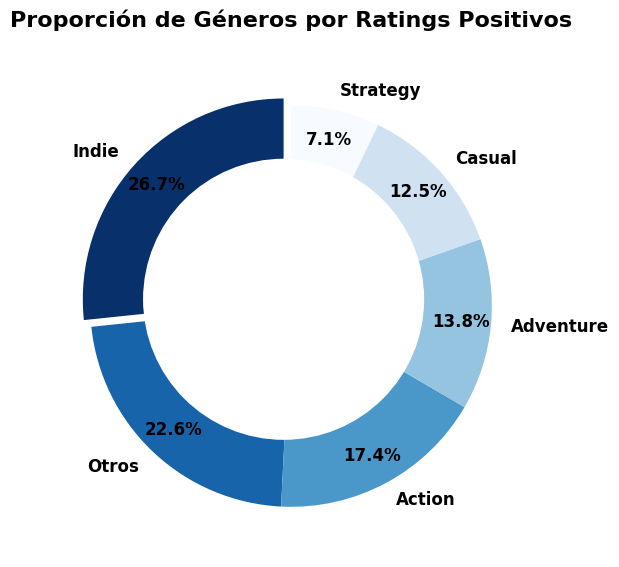

In [153]:
# Realizar gráfico de dona

colors_pie = plt.cm.Blues_r(np.linspace(0, 1, len(pie_data))) # Colores
explode_val = 0.05 # Valor de separación

# Ajuste dinámico del valor de explode
explode_arr = [explode_val] + [0] * (len(pie_data) - 1)

# Gráfico de pastel

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(pie_data,
                                   labels=pie_data.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors_pie,
                                   textprops={'fontsize': 12, 'fontweight': 'bold'},
                                   pctdistance=0.85, # Mueve el porcentaje hacia afuera
                                   explode=explode_arr) # Resalta ligeramente la porción principal

# Círculo blanco central (estilo moderno)

theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center_angle = np.deg2rad((theta1 + theta2) / 2) # Obtención el ángulo medio

cx = explode_val * np.cos(center_angle) # Se Calcula nueva posición con trigonometría
cy = explode_val * np.sin(center_angle)

centre_circle = plt.Circle((cx, cy), 0.70, fc='white') # Se dibuja el circulo
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción de Géneros por Ratings Positivos', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()